Step 1: Import Libraries and Load Dataset

We need to import the required libraries and load the dataset from scikit-learn library.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

Step 2: Split the Dataset

Loads features and labels

Splits data into training and testing sets

Ensures reproducibility using a fixed random state

In [2]:
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.2, random_state=42
)

Step 3: Train the Original (Unpruned) Decision Tree

Uses Gini impurity to measure split quality

Trains a fully grown decision tree

In [4]:
model = DecisionTreeClassifier(criterion="gini")
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Step 4: Visualize the Original Decision Tree

Large figure size improves node spacing

Reduced font size avoids overlap

Filled nodes reflect class purity

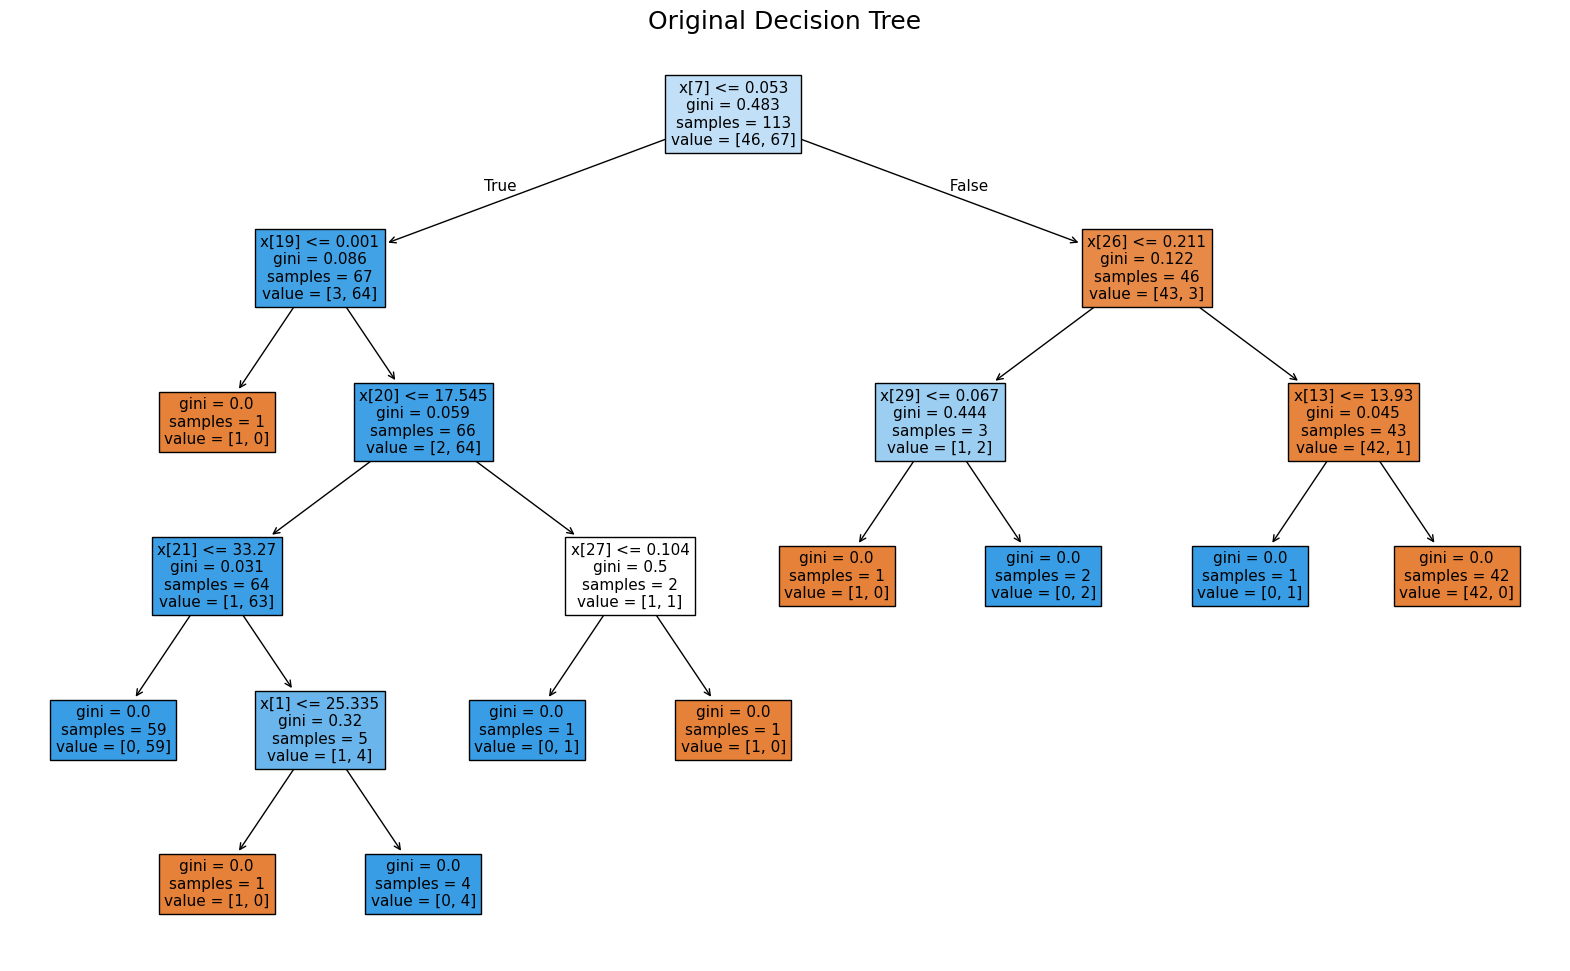

In [5]:
plt.figure(figsize=(20, 12))
plot_tree(
    model,
    filled=True,
    fontsize=11
)
plt.title("Original Decision Tree", fontsize=18)
plt.show()

Step 5: Model Accuracy Before Pruning

Here we evaluates baseline model performance

In [6]:
accuracy_before_pruning = model.score(X_test, y_test)
print("Accuracy before pruning:", accuracy_before_pruning)

Accuracy before pruning: 0.9078947368421053


Step 6: Hyperparameter Grid and GridSearchCV

Defines constraints to limit tree complexity

Uses cross-validation to find optimal settings

In [8]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [1, 2, 3, 4, 5],
    'max_features': ['sqrt', 'log2']
}

dt = DecisionTreeClassifier()
cv = GridSearchCV(dt, param_grid=parameters, cv=5)
cv.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2'], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'log_loss'


Step 7: Evaluate the Pre-Pruned Model

Displays performance after pre-pruning

Shows optimal hyperparameter values

In [9]:
print("Best Accuracy:", cv.score(X_test, y_test))
print("Best Parameters:", cv.best_params_)

Best Accuracy: 0.9122807017543859
Best Parameters: {'criterion': 'log_loss', 'max_depth': 3, 'max_features': 'sqrt', 'splitter': 'random'}


Step 8: Compute Pruning Path

Computes pruning strength values

Higher alpha values lead to simpler trees

In [10]:
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

Step 9: Train Pruned Models

Trains trees with varying levels of pruning

Creates models with different complexities

In [11]:
pruned_models = []

for alpha in ccp_alphas:
    pruned_model = DecisionTreeClassifier(
        criterion="gini",
        ccp_alpha=alpha
    )
    pruned_model.fit(X_train, y_train)
    pruned_models.append(pruned_model)

Step 10: Select the Best Pruned Model

Evaluates each pruned model

Selects the best-performing one

In [12]:
best_accuracy = 0
best_pruned_model = None

for m in pruned_models:
    acc = m.score(X_test, y_test)
    if acc > best_accuracy:
        best_accuracy = acc
        best_pruned_model = m

print("Accuracy after pruning:", best_accuracy)

Accuracy after pruning: 0.918859649122807


Step 11: Visualize the Pruned Decision Tree

Increased spacing improves readability

Shows a simplified and interpretable tree

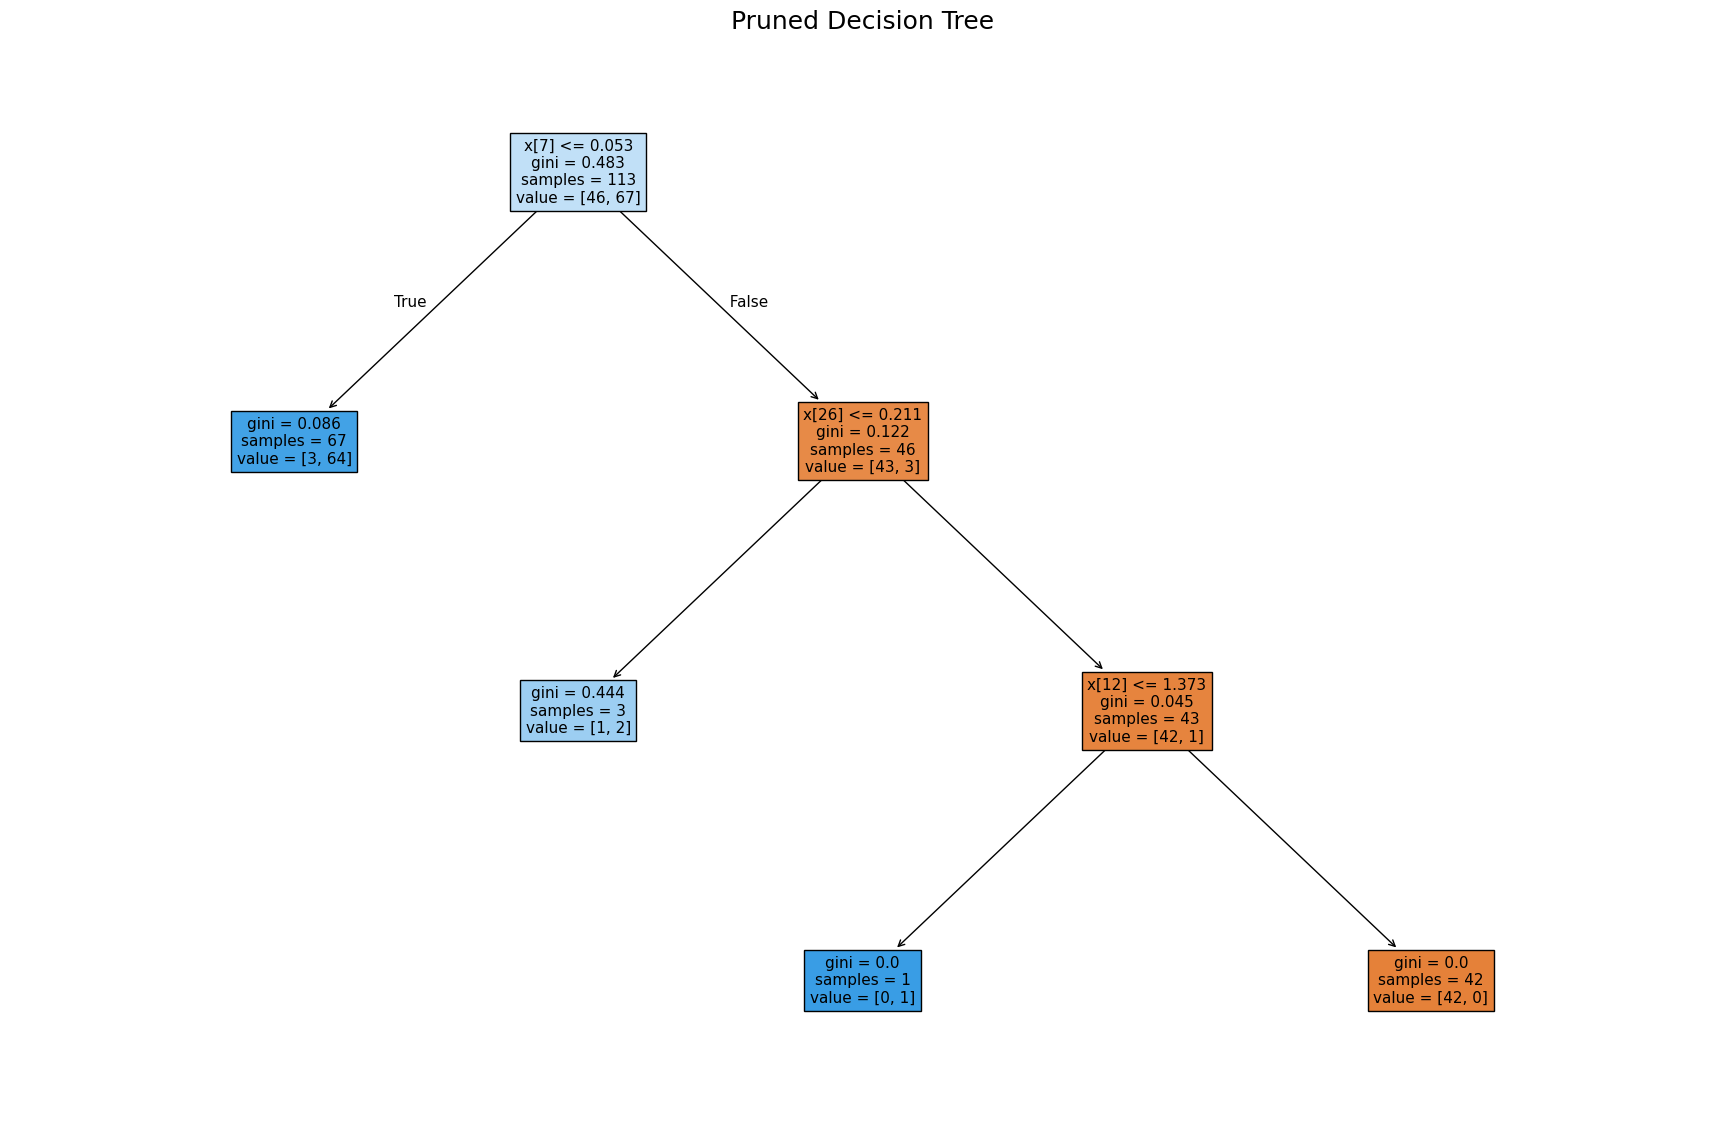

In [13]:
plt.figure(figsize=(22, 14))
plot_tree(
    best_pruned_model,
    filled=True,
    fontsize=11
)
plt.title("Pruned Decision Tree", fontsize=18)
plt.show()